In [23]:
import torch
from torch.utils.data import Dataset
import json
import cv2
import os
import numpy as np

class COCODataset(Dataset):
    def __init__(self, json_path, image_dir):
        with open(json_path) as f:
            self.data = json.load(f)

        self.image_dir = image_dir
        self.images = self.data["images"]
        self.annotations = self.data["annotations"]

        # map image_id → annotations
        self.ann_map = {}
        for ann in self.annotations:
            self.ann_map.setdefault(ann["image_id"], []).append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.image_dir, img_info["file_name"])

        # Read image
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError(f"Image not found: {img_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        height, width = img.shape[:2]

        anns = self.ann_map.get(img_info["id"], [])

        boxes = []
        labels = []
        masks = []

        for ann in anns:

            # Skip invalid segmentation
            if "segmentation" not in ann or len(ann["segmentation"]) == 0:
                continue

            # BOX → convert [x,y,w,h] → [x1,y1,x2,y2]
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])

            # Labels
            labels.append(ann["category_id"])

            # MASK from polygon
            mask = np.zeros((height, width), dtype=np.uint8)

            for seg in ann["segmentation"]:
                pts = np.array(seg).reshape(-1, 2).astype(np.int32)
                cv2.fillPoly(mask, [pts], 1)

            masks.append(mask)

        # Handle empty cases
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            masks = torch.zeros((0, height, width), dtype=torch.uint8)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks
        }

        # Convert image
        img = torch.as_tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

        return img, target

In [24]:
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn

def get_model(num_classes):
    model = maskrcnn_resnet50_fpn(weights="DEFAULT")

    # box predictor
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_features, num_classes
    )

    # mask predictor
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
        in_features_mask, 256, num_classes
    )

    return model

In [25]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

# train_dataset = COCODataset("my_merged_coco_dataset/merged_dataset.json", "my_merged_coco_dataset/images")
train_dataset = COCODataset("july/instances_default.json", "july-images")
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

In [26]:
max_label = 0

for _, targets in train_loader:
    for t in targets:
        if len(t["labels"]) > 0:
            max_label = max(max_label, t["labels"].max().item())

print("Global max label:", max_label)

Global max label: 6


In [27]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = get_model(num_classes=7)
model.to(device)

# Replace your current Adam optimizer with this:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# Drops the learning rate by 10x every 15 epochs
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)


In [28]:
for epoch in range(25):
    model.train()
    total_loss = 0

    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: Loss = {total_loss:.4f}")

# torch.save(model.state_dict(), "mask_rcnn_model.pth")
torch.save(model.state_dict(), "mask_rcnn_model_july.pth")
print("✅ Model saved!")

Epoch 0: Loss = 496.7557
Epoch 1: Loss = 383.7725
Epoch 2: Loss = 330.8878
Epoch 3: Loss = 286.9157
Epoch 4: Loss = 254.7737
Epoch 5: Loss = 226.6130
Epoch 6: Loss = 207.1011
Epoch 7: Loss = 184.2190
Epoch 8: Loss = 171.2994
Epoch 9: Loss = 155.8894
Epoch 10: Loss = 148.0766
Epoch 11: Loss = 138.6378
Epoch 12: Loss = 143.8979
Epoch 13: Loss = 132.5250
Epoch 14: Loss = 123.5159
Epoch 15: Loss = 117.2650
Epoch 16: Loss = 114.4740
Epoch 17: Loss = 109.6774
Epoch 18: Loss = 106.9432
Epoch 19: Loss = 102.8961
Epoch 20: Loss = 103.5811
Epoch 21: Loss = 100.0298
Epoch 22: Loss = 98.8427
Epoch 23: Loss = 101.8638
Epoch 24: Loss = 110.5472
✅ Model saved!


In [29]:
model = get_model(num_classes=7)
# model.load_state_dict(torch.load("mask_rcnn_model.pth"))
model.load_state_dict(torch.load("mask_rcnn_model_july.pth"))
model.to(device)
model.eval()

print("✅ Model loaded!")

✅ Model loaded!


In [30]:
model.eval()

with torch.no_grad():
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)
        print(outputs[0])
        break

{'boxes': tensor([[ 207.0169,  414.0097,  554.9376,  577.9142],
        [ 187.4409,  472.5382, 1705.6284,  708.8246],
        [ 723.7657,  173.1820,  966.5548,  456.5496],
        [1417.8944,    0.0000, 1919.0000,  542.6998],
        [1233.7780,    0.0000, 1443.7563,  457.2038],
        [1237.9691,    0.0000, 1445.4026,  446.6768]], device='cuda:0'), 'labels': tensor([5, 3, 6, 6, 6, 1], device='cuda:0'), 'scores': tensor([0.9979, 0.9965, 0.9965, 0.9907, 0.9650, 0.2474], device='cuda:0'), 'masks': tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000

In [31]:
images, targets = next(iter(train_loader))
images = [img.to(device) for img in images]

model.eval()
with torch.no_grad():
    outputs = model(images)

In [32]:
CLASS_NAMES = [
    "__background__",
    "full_house",
    "wall",
    "road",
    "tree",
    "car",
    "shop"
]

In [33]:
pred = outputs[0]

threshold = 0.7
keep = pred["scores"] > threshold

masks = pred["masks"][keep]   # shape: [N,1,H,W]
labels = pred["labels"][keep]
scores = pred["scores"][keep]

In [34]:
threshold = 0.8

outputs = model(images)
pred = outputs[0]

keep = pred["scores"] > threshold

filtered = {
    "boxes": pred["boxes"][keep],
    "labels": pred["labels"][keep],
    "scores": pred["scores"][keep],
    "masks": pred["masks"][keep]
}

In [35]:
masks = masks.squeeze(1).detach().cpu().numpy()

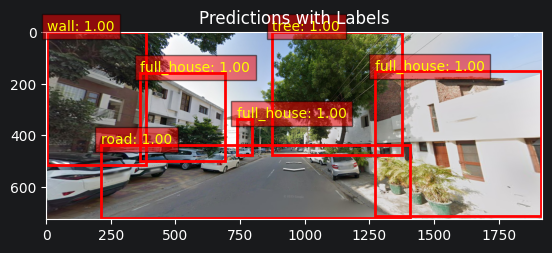

In [36]:
import matplotlib.pyplot as plt

img = images[0].cpu().permute(1,2,0).numpy()

plt.imshow(img)

for box, label, score in zip(
    filtered["boxes"].cpu(),
    filtered["labels"].cpu(),
    filtered["scores"].cpu()
):
    x1, y1, x2, y2 = box.tolist()

    class_name = CLASS_NAMES[label]
    text = f"{class_name}: {score:.2f}"

    # Draw box
    plt.gca().add_patch(
        plt.Rectangle((x1, y1), x2-x1, y2-y1,
                      edgecolor='red', fill=False, linewidth=2)
    )

    # Draw label text
    plt.text(
        x1, y1 - 5,
        text,
        color='yellow',
        fontsize=10,
        bbox=dict(facecolor='red', alpha=0.5)
    )

plt.title("Predictions with Labels")
plt.show()

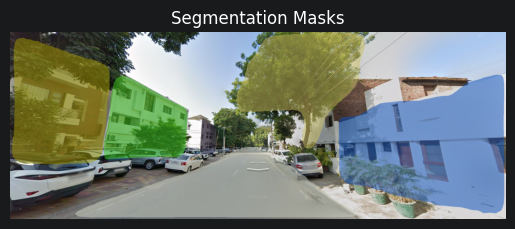

In [37]:
import numpy as np
import matplotlib.pyplot as plt

img = images[0].cpu().permute(1,2,0).numpy()
overlay = img.copy()

for i, mask in enumerate(masks):
    binary_mask = mask > 0.5   # threshold mask

    color = np.random.rand(3)  # random color per object

    overlay[binary_mask] = overlay[binary_mask] * 0.5 + color * 0.5

plt.imshow(overlay)
plt.title("Segmentation Masks")
plt.axis("off")
plt.show()

In [38]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

metric = MeanAveragePrecision(iou_type="segm")  # for masks

In [39]:
from torchvision.datasets import CocoDetection
from pycocotools.coco import COCO
import torch

class CocoDetectionCustom(CocoDetection):
    def __getitem__(self, idx):

        img, anns = super().__getitem__(idx)
        img = transform(img)
        boxes = []
        labels = []
        masks = []

        for ann in anns:
            xmin, ymin, w, h = ann['bbox']
            boxes.append([xmin, ymin, xmin + w, ymin + h])
            labels.append(ann['category_id'])

            if 'segmentation' in ann:
                mask = self.coco.annToMask(ann)
                masks.append(mask)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        if len(masks) > 0:
            # We have to use np.array to avoid a slow warning if masks is a list of arrays
            masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)
        else:
            # Fix: Use the tensor's shape instead of PIL attributes
            masks = torch.zeros((0, img.shape[1], img.shape[2]), dtype=torch.uint8)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks
        }

        return img, target

In [40]:
import torchvision.transforms as T

# Define the transform to convert PIL images to PyTorch tensors
transform = T.ToTensor()

In [41]:
val_dataset = CocoDetectionCustom(
    root="val_anu",
    annFile="instances_default.json"
)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [42]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

In [43]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

metric = MeanAveragePrecision(iou_type="segm")

model.eval()

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]

        outputs = model(images)

        preds = []
        gts = []

        for out, tgt in zip(outputs, targets):
            preds.append({
                "boxes": out["boxes"].cpu(),
                "scores": out["scores"].cpu(),
                "labels": out["labels"].cpu(),
                # Fix: Apply a > 0.5 threshold and cast to uint8
                "masks": (out["masks"].squeeze(1) > 0.5).to(torch.uint8).cpu()
            })

            gts.append({
                "boxes": tgt["boxes"].cpu(),
                "labels": tgt["labels"].cpu(),
                "masks": tgt["masks"].cpu()
            })

        metric.update(preds, gts)

results = metric.compute()
print(results)

{'map': tensor(0.4207), 'map_50': tensor(0.4933), 'map_75': tensor(0.4854), 'map_small': tensor(-1.), 'map_medium': tensor(-1.), 'map_large': tensor(0.4207), 'mar_1': tensor(0.3898), 'mar_10': tensor(0.4313), 'mar_100': tensor(0.4313), 'mar_small': tensor(-1.), 'mar_medium': tensor(-1.), 'mar_large': tensor(0.4313), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([1, 2, 3, 4, 5, 6], dtype=torch.int32)}
